In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import os
from scipy.signal import find_peaks
from scipy import constants
from lmfit.models import LinearModel
from lmfit import Model
from scipy.stats import pearsonr

## Campo Magnético

#### Funciones

In [19]:
def plot_B(data_path, n):
    df = pd.read_csv('data/' + data_path)
    B_all = df['B [G]']
    dB_all = df['dB [G]']
    B = df['B [G]'][:n]
    dB = df['dB [G]'][:n]
    I_all = df['I [A]']
    dI_all = df['dI [A]']
    I = df['I [A]'][:n]
    dI = df['dI [A]'][:n]

    modelo = LinearModel()
    result = modelo.fit(B, x=I, weights=1 / dB)
    x = np.linspace(I.min(), I.max(), 1000)
    m_val = result.params['slope'].value
    m_err = result.params['slope'].stderr
    b_val = result.params['intercept'].value
    b_err = result.params['intercept'].stderr
    sigma = result.eval_uncertainty(x=x, sigma=1)

   
    Bfit = m_val*x + b_val
    print(result.fit_report())

    fig, ax = plt.subplots(figsize= (9, 6), dpi=300)

    ax.errorbar(I, B, xerr = dI, yerr = dB, color='k', fmt = 's',label='Datos Experimantales', markersize =2, capsize = 0, zorder = 1)
    plt.plot(x, Bfit, color="blue",linewidth=1, label="Ajuste Lineal ($R$ = 0.9998)", zorder=2)

    plt.fill_between(
    x,
    Bfit - sigma,  
    Bfit + sigma,
    color="blue",
    alpha=0.15, 
    label="Desviación Estándar del Ajuste",
    zorder=2,
)

    texto_ecuacion = (
    f"$m = {m_val:.4f} \pm {m_err:.4f}$\n"
    f"$b = {b_val:.4f} \pm {b_err:.4f}$")

    propiedades_cuadro = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8)
    ax.text(0.95, 0.05, texto_ecuacion, 
            transform=ax.transAxes, # <-- Esto hace la magia
            fontsize=10, 
            bbox=propiedades_cuadro, 
            verticalalignment='bottom',
            horizontalalignment='right')

    

    ax.set_title(f'Campo Magnético del Electroimán con Núcleos de Hierro ' + '$B$', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Corriente $I$ [A]', fontsize=12)
    ax.set_ylabel('Campo Magnético $B$ [G]', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig('plots/magnetic_field.png', bbox_inches='tight')
    plt.show()
    return m_val, b_val

[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 181
    # variables        = 2
    chi-square         = 7688.21167
    reduced chi-square = 42.9509032
    Akaike info crit   = 682.559308
    Bayesian info crit = 688.956302
    R-squared          = 0.99989476
[[Variables]]
    slope:      427.801340 +/- 0.32803472 (0.08%) (init = 1)
    intercept: -15.9658438 +/- 0.71982280 (4.51%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.7362


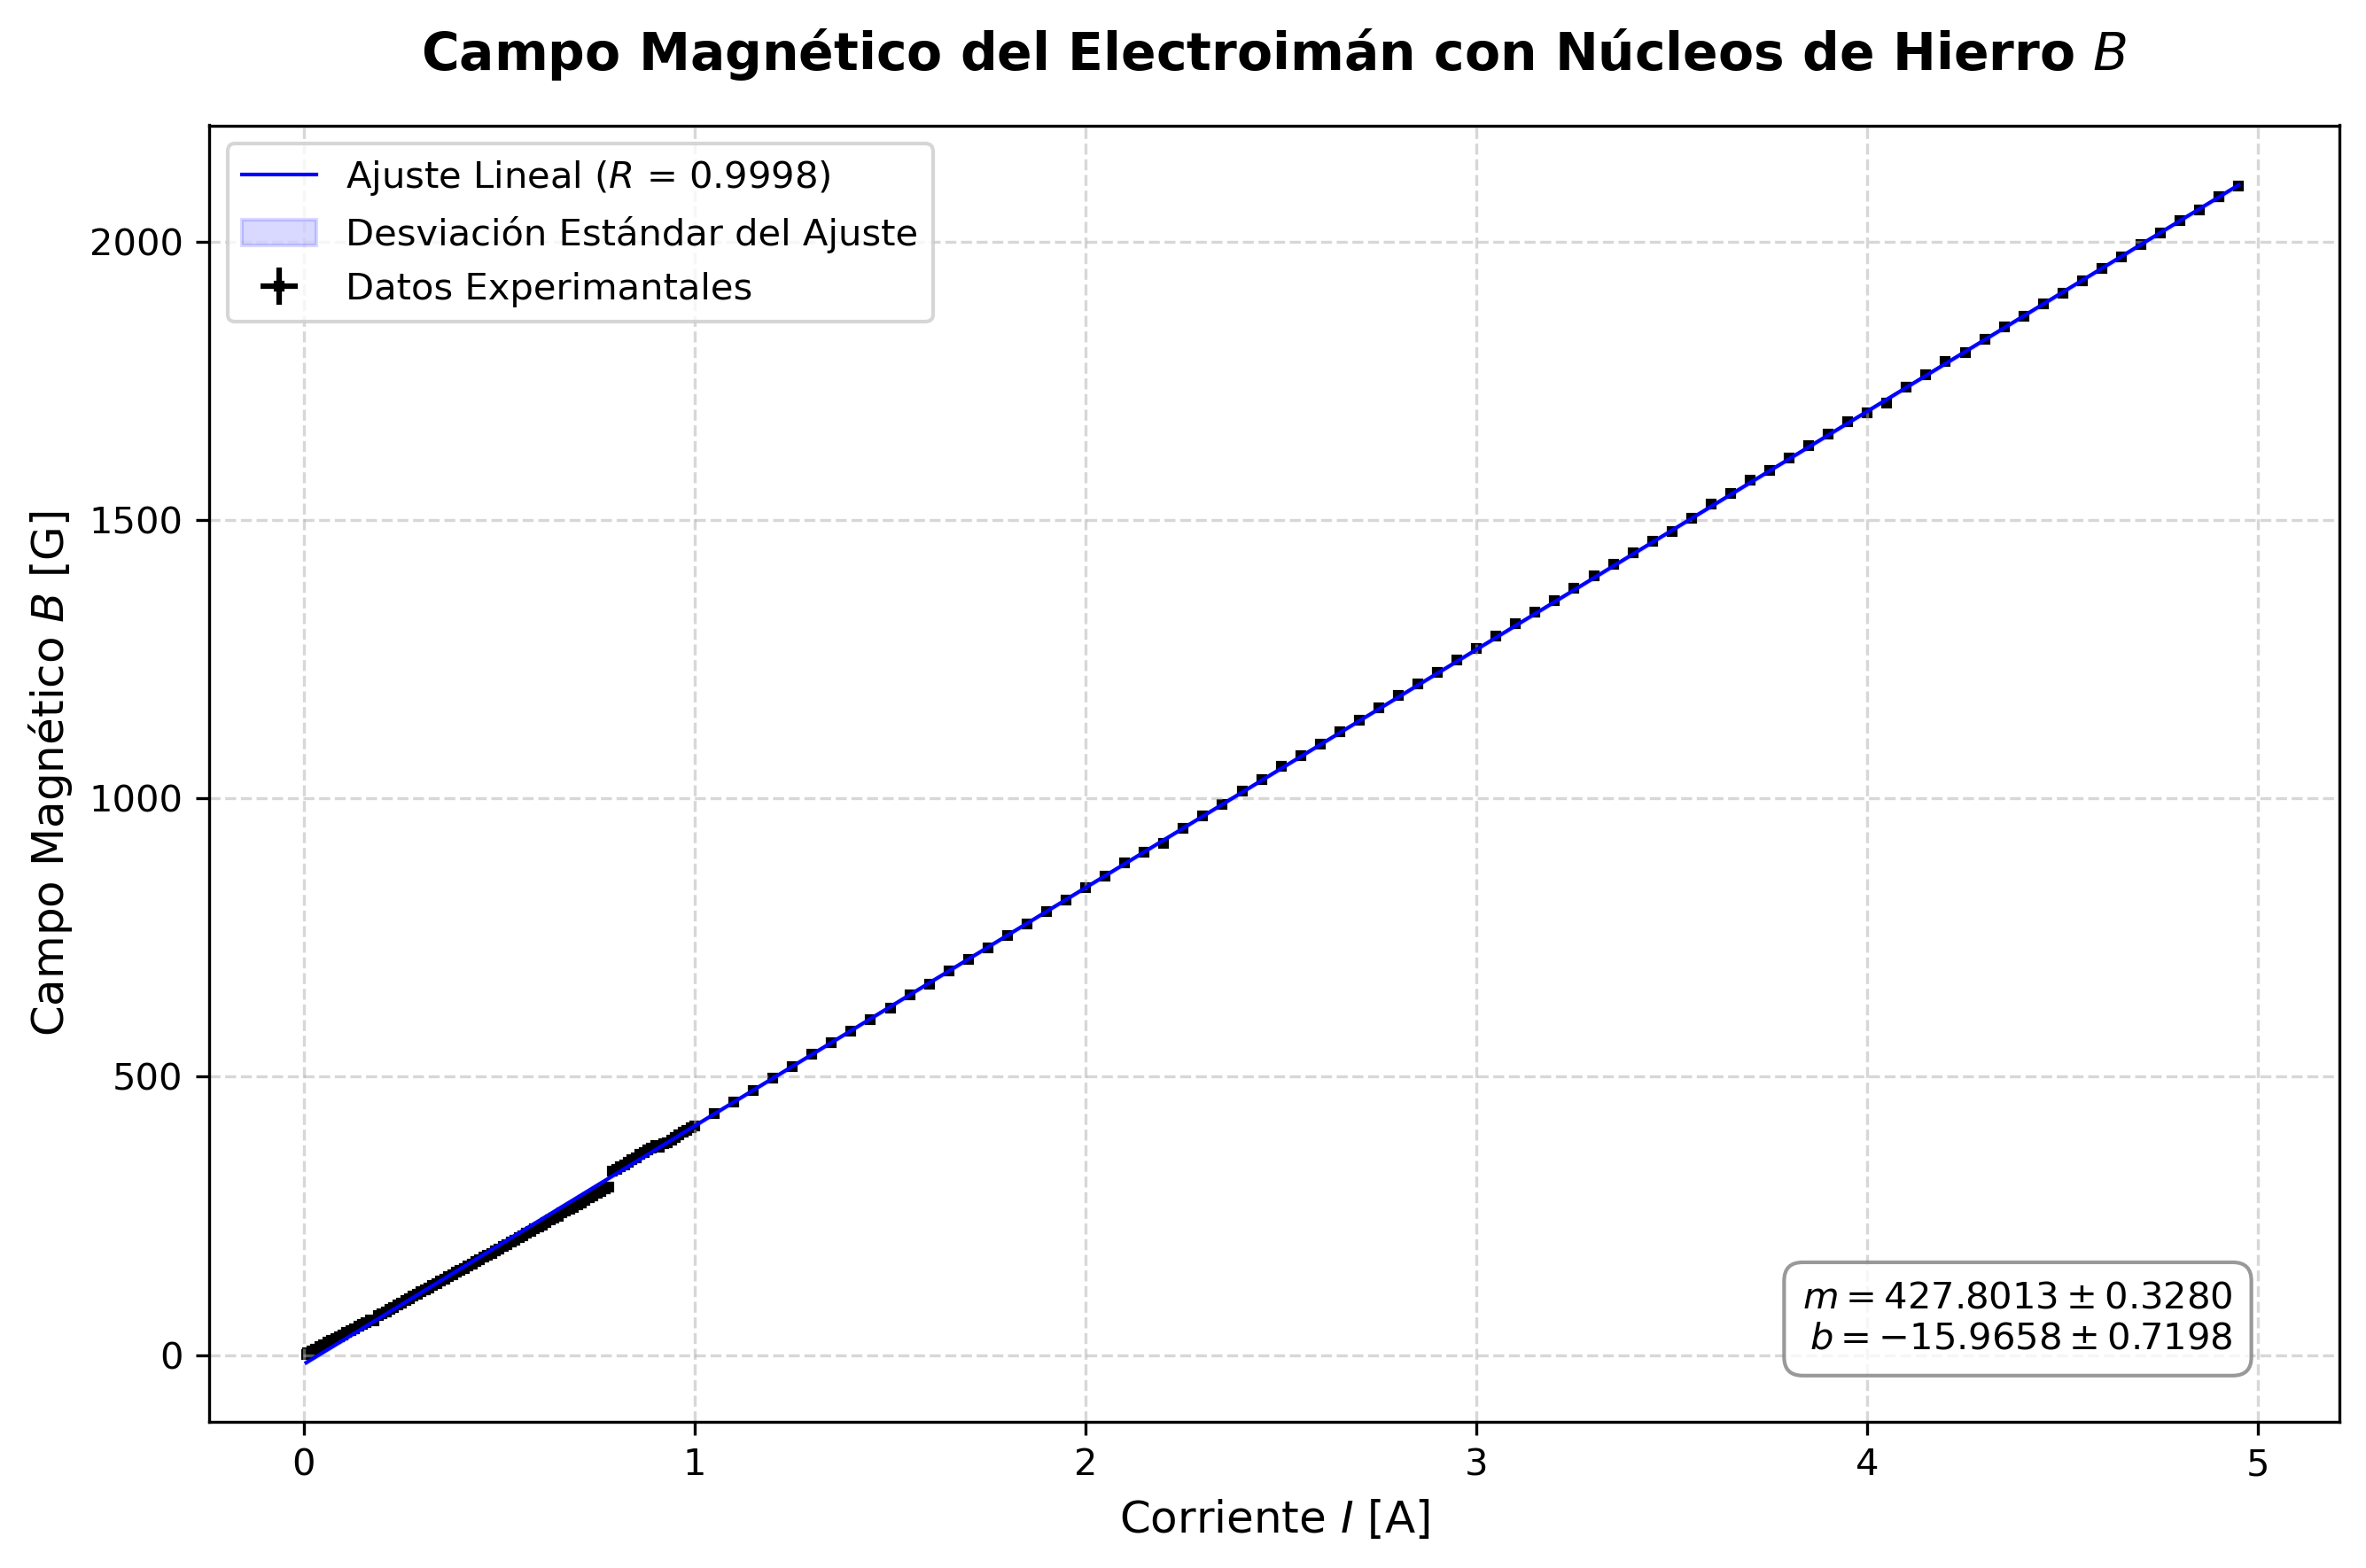

In [20]:
m , b = plot_B('magnetic_field_14_05_26.csv', n = 181)

## Efecto Faraday

### Método de Extinción

#### Funciones

In [43]:
def plot_vernet(data_path, crystal, slope, intercept, method):
    df = pd.read_csv('data/' +  data_path)

    df_cristal = df[df["Flint"] == crystal]

    if df_cristal.empty:
        print(f"Error: No se encontraron datos para el cristal '{cristal_buscado}'")
        return
    
    longitudes_unicas = df_cristal["L [cm]"].unique()

    lista_L = []
    lista_m = []
    lista_b = []
    lista_V = []
    lista_r2 = []

    plt.figure(figsize=(10, 7))
    lista_V = []
    colores = colormaps.get_cmap("tab10")( len(longitudes_unicas))
    
    for i, longitud in enumerate(longitudes_unicas):
        df_longitud = df_cristal[df_cristal["L [cm]"] == longitud]
        I = df_longitud["I [A]"].values
        dI = df_longitud["dI [A]"].values
        B = (slope*I + intercept)*1e-4
        dB = (slope*dI)*1e-4
        theta = df_longitud["t [deg]"].values
        dtheta = df_longitud["dt [deg]"].values

        modelo = LinearModel()
        resultado = modelo.fit(theta, x=B, weights = 1/dtheta)

        m = resultado.params["slope"].value
        b = resultado.params["intercept"].value

        B_recta = np.linspace(B.min(), B.max(), 500)
        theta_recta = m * B_recta + b
        sigma = resultado.eval_uncertainty(x=B_recta, sigma=1)

        color_actual = tuple(plt.cm.tab10(i % 10))
        plt.errorbar(B, theta, xerr = dB, yerr = dtheta, fmt="s", color=color_actual, ms=4, alpha=0.7, label=f"Datos L = {longitud} mm", zorder=2)
        plt.plot(B_recta, theta_recta, color=color_actual, linestyle="--", linewidth=1, label=f"Ajuste L={longitud} (m={m:.2f}, b={b:.2f})",zorder=3)

        m_actual = resultado.params["slope"].value
        b_actual = resultado.params["intercept"].value
        V_actual = (m_actual / longitud)*(np.pi*100/180)
        r2_actual = resultado.rsquared

        lista_L.append(longitud)
        lista_m.append(m_actual)
        lista_b.append(b_actual)
        lista_V.append(V_actual)
        lista_r2.append(r2_actual)

    plt.title(f"Método de Extinción - Cristal Flint {crystal}",fontsize=14, fontweight="bold")
    plt.xlabel("Campo Magnético $B$ [T]", fontsize=12)
    plt.ylabel(r"Ángulo de Rotación $\theta$ [deg]", fontsize=12)

    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(bbox_to_anchor=(0, -0.15), loc="upper left", fontsize=10, ncol = 2)

    plt.tight_layout()
    plt.savefig(f'plots/faraday_effect_{crystal}_{method}.png', bbox_inches='tight')
    plt.show()

    arr_V = np.array(lista_V)

    V_promedio = np.mean(arr_V)
    V_desviacion = np.std(arr_V, ddof=1)

    datos_resumen = {
    "Longitud [cm]": lista_L,
    "Pendiente m": lista_m,
    "Ordenada b": lista_b,
    "V [rad*T⁻¹*m⁻¹]": lista_V,
    "Correlación (R²)": lista_r2}

    df_resumen = pd.DataFrame(datos_resumen)

    print("\n" + "=" * 80)
    print(f"TABLA RESUMEN DE RESULTADOS: CRISTAL {crystal}")
    print("=" * 80)
    print(df_resumen.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
    print("=" * 80 + "\n")
    print(f"Constante de Verdet (V) promedio para Vidrio Flint {crystal}: ({V_promedio:.4f}  \u00b1 {V_desviacion:.4f}) rad T\u207B\u00B9 m\u207B\u00B9")
    

#### Método de Extinción (a ojímetro)

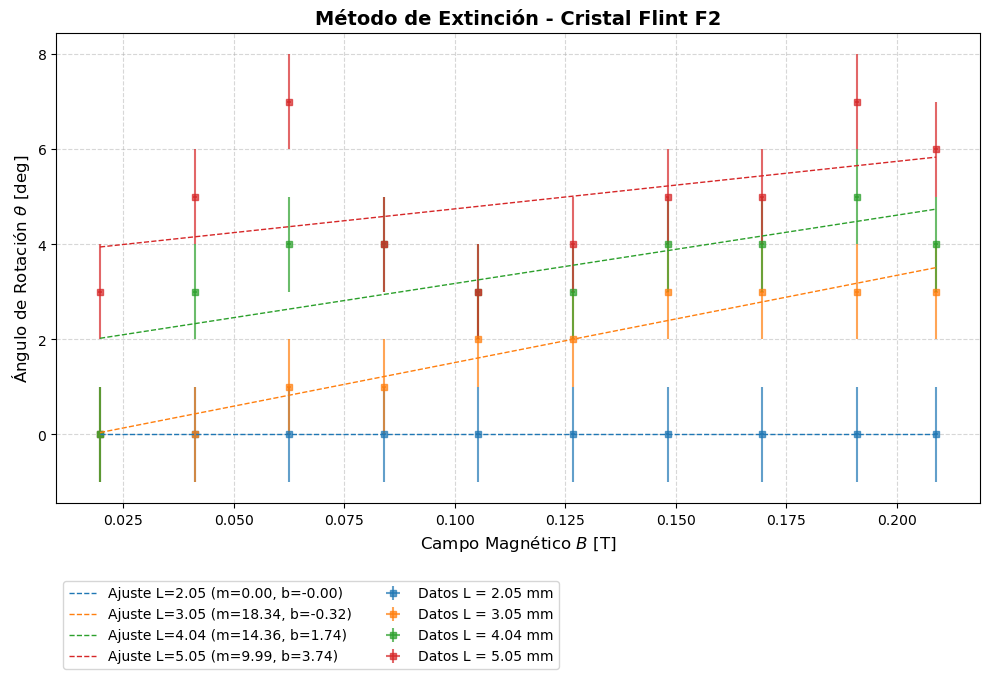


TABLA RESUMEN DE RESULTADOS: CRISTAL F2
 Longitud [cm]  Pendiente m  Ordenada b  V [rad*T⁻¹*m⁻¹]  Correlación (R²)
       2.05000      0.00000    -0.00000          0.00000           1.00000
       3.05000     18.33978    -0.32203         10.49474           0.91750
       4.04000     14.35909     1.73856          6.20330           0.46641
       5.05000      9.98863     3.74425          3.45217           0.19584

Constante de Verdet (V) promedio para Vidrio Flint F2: (5.0376  ± 4.4358) rad T⁻¹ m⁻¹


In [44]:
plot_vernet("flint_crystals_19_05_26.csv", "F2", slope=m, intercept=b, method ='eye')

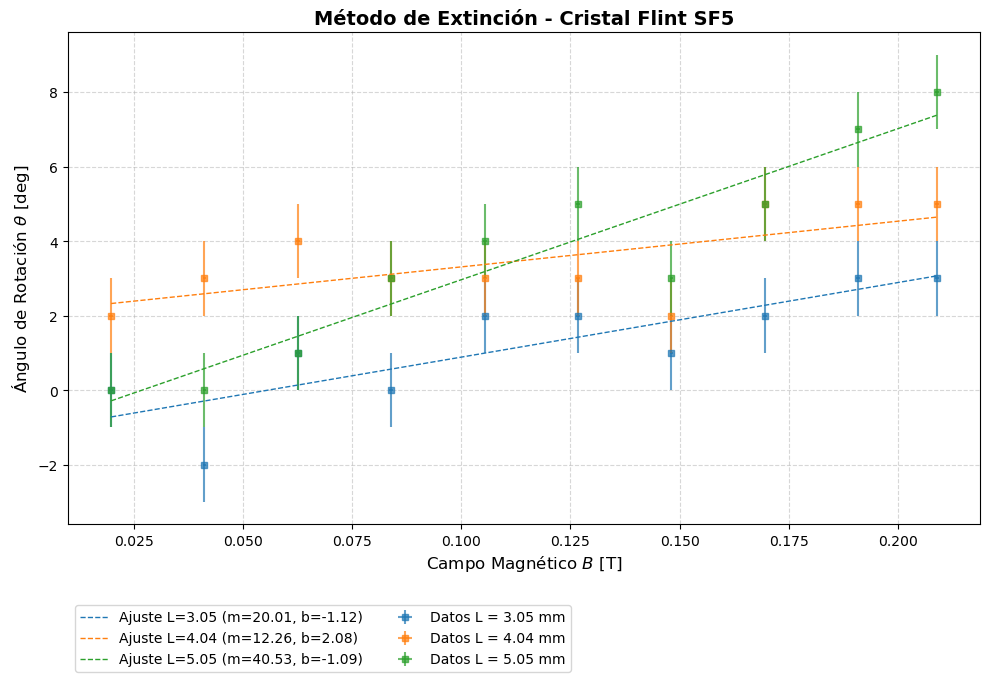


TABLA RESUMEN DE RESULTADOS: CRISTAL SF5
 Longitud [cm]  Pendiente m  Ordenada b  V [rad*T⁻¹*m⁻¹]  Correlación (R²)
       3.05000     20.01416    -1.11577         11.45289           0.68798
       4.04000     12.25804     2.08166          5.29562           0.44595
       5.05000     40.53111    -1.08971         14.00795           0.89099

Constante de Verdet (V) promedio para Vidrio Flint SF5: (10.2522  ± 4.4786) rad T⁻¹ m⁻¹


In [45]:
plot_vernet("flint_crystals_19_05_26.csv", "SF5", slope=m, intercept=b, method = 'eye')

#### Método de Extinción (con Fotodiodo)

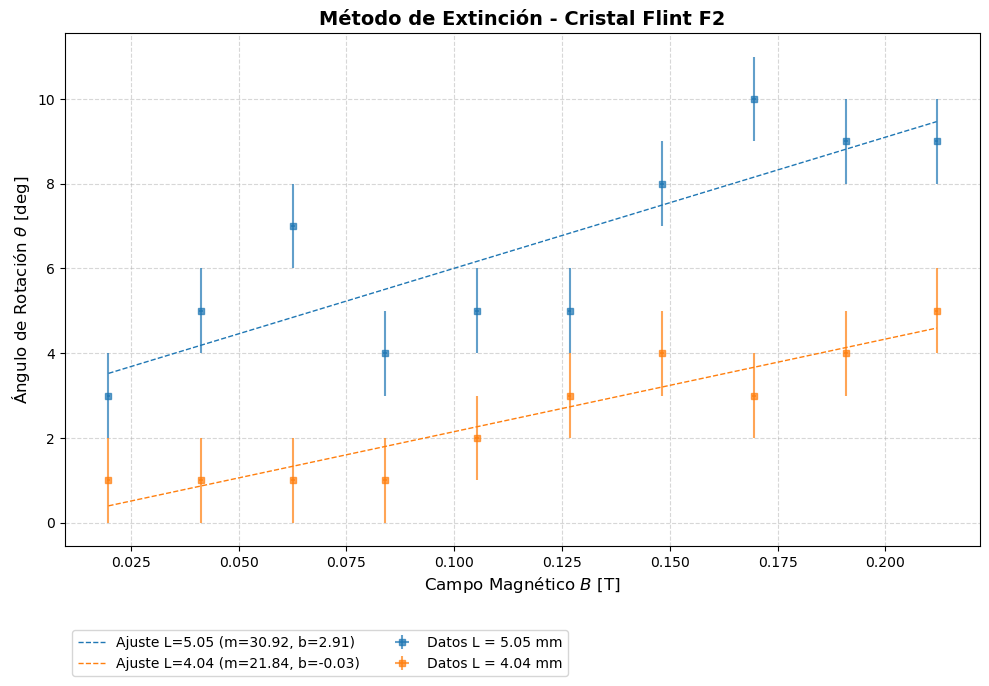


TABLA RESUMEN DE RESULTADOS: CRISTAL F2
 Longitud [cm]  Pendiente m  Ordenada b  V [rad*T⁻¹*m⁻¹]  Correlación (R²)
       5.05000     30.92278     2.91277         10.68721           0.68601
       4.04000     21.83619    -0.03313          9.43350           0.87606

Constante de Verdet (V) promedio para Vidrio Flint F2: (10.0604  ± 0.8865) rad T⁻¹ m⁻¹


In [46]:
plot_vernet("flint_crystals_21_05_26.csv", "F2", slope=m, intercept=b, method = 'ext')

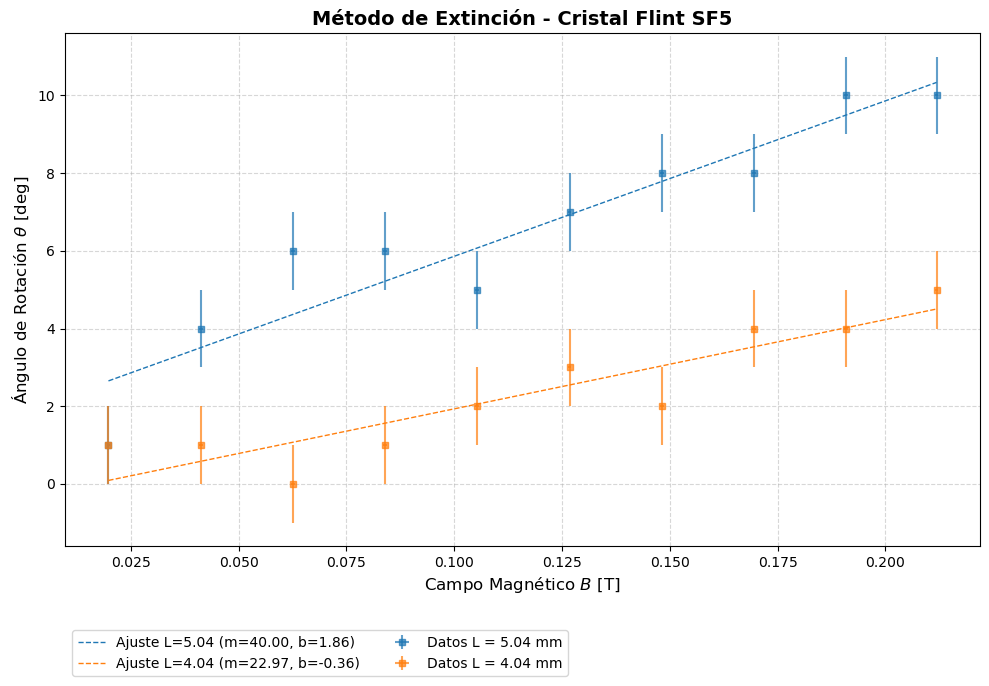


TABLA RESUMEN DE RESULTADOS: CRISTAL SF5
 Longitud [cm]  Pendiente m  Ordenada b  V [rad*T⁻¹*m⁻¹]  Correlación (R²)
       5.04000     39.99800     1.85999         13.85113           0.87967
       4.04000     22.96974    -0.36463          9.92321           0.82457

Constante de Verdet (V) promedio para Vidrio Flint SF5: (11.8872  ± 2.7775) rad T⁻¹ m⁻¹


In [47]:
plot_vernet("flint_crystals_21_05_26.csv", "SF5", slope=m, intercept=b, method = 'ext')

### Método de Ley de Malus

#### Funciones

In [48]:
def ley_malus(t, I0, t0, I_fondo):
    t_rad = np.radians(t)
    t0_rad = np.radians(t0)
    return I0 * (np.cos(t_rad - t0_rad) ** 2) + I_fondo

def plot_malus(data_path, cristal_buscado, m_calib, b_calib):
    df = pd.read_csv('data/'+data_path)
    df.columns = df.columns.str.strip()

    df_cristal = df[df["Flint"] == cristal_buscado]

    if df_cristal.empty:
        print(f"Error: No se hallaron datos para '{cristal_buscado}'")
        return

    longitudes_unicas = df_cristal["L [cm]"].unique()

    # Listas para almacenar datos de la tabla
    lista_L = []
    lista_m = []
    lista_b = []
    lista_r2 = []
    lista_V = []  # Almacenará V en rad * T^-1 * m^-1

    plt.figure(figsize=(10, 7))

    for i, longitud in enumerate(longitudes_unicas):
        df_longitud = df_cristal[df_cristal["L [cm]"] == longitud]

        t_exp = df_longitud["t [deg]"].values.astype(float)
        dt_exp = df_longitud["dt [deg]"].values.astype(float)
        I_exp = df_longitud["I [nA]"].values.astype(float)
        dI_exp = df_longitud["dI [nA]"].values.astype(float)

        # Tomamos el valor de la corriente del electroimán (I0 [A] en tu tabla)
        I_electroiman = df_longitud["I0 [A]"].values[0]

        # Calculamos el Campo Magnético B para esta longitud usando la calibración
        B_campo = m_calib * I_electroiman + b_calib

        # --- AJUSTE CON GUESSES MEJORADOS PARA FORMA DE "U" ---
        modelo = Model(ley_malus, independent_vars=["t"])
        params = modelo.make_params()

        amplitud_aprox = max(I_exp) - min(I_exp)
        angulo_minimo = t_exp[np.argmin(I_exp)]
        t0_estimado = angulo_minimo + 90  # El máximo está a 90° del mínimo

        params["I0"].set(value=amplitud_aprox * 2, min=0)
        params["t0"].set(value=t0_estimado, min=-270, max=270)
        params["I_fondo"].set(value=min(I_exp), min=0)

        resultado = modelo.fit(I_exp, params, t=t_exp, weights=1.0 / dI_exp)

        # Extraer parámetros optimizados
        I0_opt = resultado.params["I0"].value
        t0_opt = resultado.params["t0"].value
        I_fondo_opt = resultado.params["I_fondo"].value
        r2 = resultado.rsquared

        # --- CÁLCULO DE LA CONSTANTE DE VERDET (V) ---
        # t0_opt está en grados, lo pasamos a radianes
        theta_rad = np.radians(t0_opt)
        # Longitud de centímetros a metros
        L_metros = longitud / 100.0

        # V = theta / (B * L) -> Unidades: rad * T^-1 * m^-1
        V_calculada = theta_rad *1000/ (B_campo * L_metros)

        # Guardar datos en las listas
        lista_L.append(longitud)
        lista_m.append(I0_opt)  # m es la amplitud máxima de intensidad (I0)
        lista_b.append(I_fondo_opt)  # b es el ruido de fondo
        lista_r2.append(r2)
        lista_V.append(V_calculada)

        color_actual = tuple(plt.cm.tab10(i % 10))

        plt.errorbar(t_exp,I_exp,xerr=dt_exp, yerr=dI_exp, fmt="s", color=color_actual, ms=4, capsize=2,
                     elinewidth=0.8,alpha=0.7,label=f"Datos L = {longitud} cm",zorder=2)

        t_recta = np.linspace(t_exp.min(), t_exp.max(), 1000)
        I_recta = ley_malus(t_recta, I0_opt, t0_opt, I_fondo_opt)
        plt.plot(t_recta,I_recta,color=color_actual,linewidth=1, linestyle = '--', 
                 label=f"Ajuste L = {longitud} cm ($R^2$ = {r2:.4f})",zorder=3,)
        d_I = resultado.eval_uncertainty(t=t_recta, sigma=1)
        plt.fill_between(t_recta,I_recta - d_I,I_recta + d_I,color=color_actual,alpha=0.08,zorder=1)

    plt.title(
        f"Ley de Malus - Cristal {cristal_buscado}",
        fontsize=13,
        fontweight="bold",
    )
    plt.xlabel("Ángulo de Rotación $t$ [deg]", fontsize=11)
    plt.ylabel("Intensidad de Corriente $I$ [nA]", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(bbox_to_anchor=(0, -0.15), loc="upper left", fontsize=10, ncol =2)
    plt.tight_layout()
    plt.savefig(f'plots/faraday_effect_{cristal_buscado}_malus.png', bbox_inches='tight')
    plt.show()

    # ==========================================
    # 3. TABLA RESUMEN Y ESTADÍSTICA FINAL
    # ==========================================
    df_resumen = pd.DataFrame(
        {
            "Longitud [cm]": lista_L,
            "Amplitud m (I0)": lista_m,
            "Fondo b (I_fondo)": lista_b,
            "V [rad T⁻¹ m⁻¹]": lista_V,
            "Correlación (R²)": lista_r2,
        }
    )

    print("\n" + "=" * 90)
    print(f"TABLA RESUMEN DE RESULTADOS: VIDRIO FLINT {cristal_buscado}")
    print("=" * 90)
    print(df_resumen.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print("-" * 90)

    # Cálculo del promedio estadístico y la desviación estándar de V
    arr_V = np.array(lista_V)
    V_promedio = np.mean(arr_V)
    # ddof=1 para desviación estándar muestral. Si es un solo dato, evitar división por cero:
    V_desviacion = np.std(arr_V, ddof=1) if len(arr_V) > 1 else 0.0

    print(
        f"Constante de Verdet (V) promedio para Vidrio Flint {cristal_buscado}: ({V_promedio:.4f} ± {V_desviacion:.4f}) rad T⁻¹ m⁻¹"
    )
    print("=" * 90)

#### Método de Ley de Malus

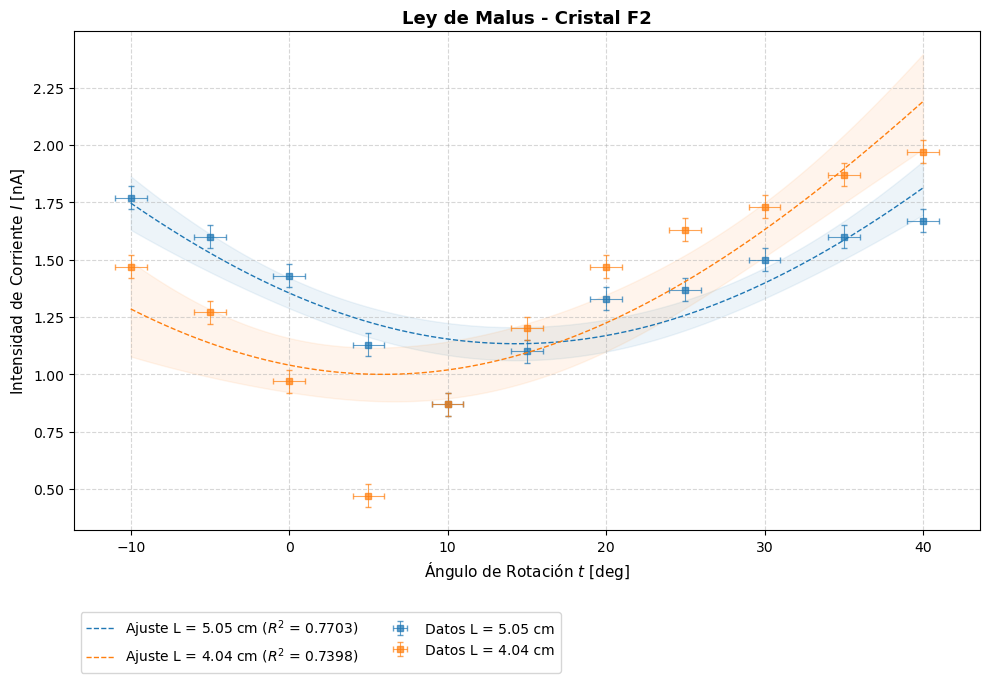


TABLA RESUMEN DE RESULTADOS: VIDRIO FLINT F2
 Longitud [cm]  Amplitud m (I0)  Fondo b (I_fondo)  V [rad T⁻¹ m⁻¹]  Correlación (R²)
        5.0500           3.6171             1.1336          17.1547            0.7703
        4.0400           3.7894             1.0000          19.6776            0.7398
------------------------------------------------------------------------------------------
Constante de Verdet (V) promedio para Vidrio Flint F2: (18.4162 ± 1.7840) rad T⁻¹ m⁻¹


In [49]:
plot_malus("flint_malus_21_05_26.csv", "F2", m, b)

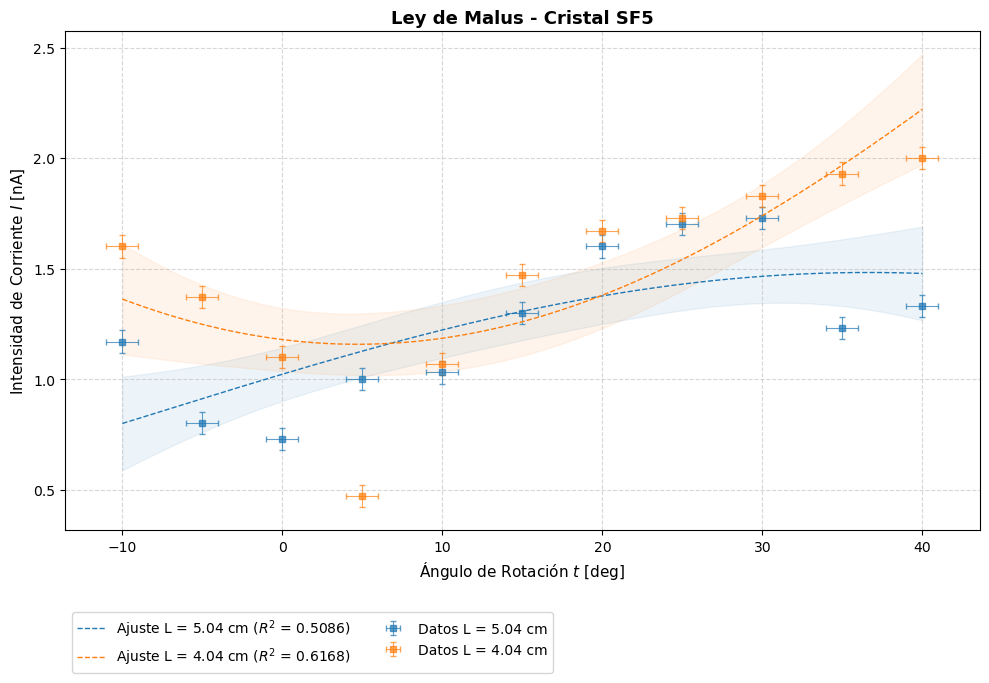


TABLA RESUMEN DE RESULTADOS: VIDRIO FLINT SF5
 Longitud [cm]  Amplitud m (I0)  Fondo b (I_fondo)  V [rad T⁻¹ m⁻¹]  Correlación (R²)
        5.0400           1.2916             0.1908           6.0382            0.5086
        4.0400           3.1811             1.1576          19.4625            0.6168
------------------------------------------------------------------------------------------
Constante de Verdet (V) promedio para Vidrio Flint SF5: (12.7503 ± 9.4924) rad T⁻¹ m⁻¹


In [50]:
plot_malus("flint_malus_21_05_26.csv", "SF5", m, b)